# Stock Predictor V1 — GOOG

Comparative analysis of five Machine Learning models to predict the closing price of Alphabet Inc. ($GOOG). The goal is to evaluate how traditional statistical models perform against non-linear algorithms, and to document daily predictions to build a real backtest history.

**Models compared:**
1. **Simple Linear Regression** — uses only the current day's closing price
2. **Linear Regression + MA5** — adds the 5-day moving average as a feature
3. **Random Forest (basic)** — uses closing price and volume
4. **Random Forest (pro)** — adds RSI and volatility as additional features
5. **SVR (Support Vector Regression)** — structural margin model with RBF kernel

> **Note:** This is V1 of the project. Known limitations (scaler data leakage, single-split evaluation) are fixed in V2.

In [5]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\agusm\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


df = yf.download('GOOG', period='1y')
df['Next_Close'] = df['Close'].shift(-1)
df_clean = df.dropna()


X = df_clean[['Close']].values
y = df_clean['Next_Close'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

modelo_simple = LinearRegression().fit(X_train, y_train)


ultimo_precio = df_clean['Close'].iloc[-1]
if hasattr(ultimo_precio, 'values'): ultimo_precio = ultimo_precio.values[0]


pred_viernes_simple = modelo_simple.predict(np.array([[float(ultimo_precio)]]))[0]

print(f"--- PREDICCIÓN SIMPLE ---")
print(f"Precio de cierre hoy: ${float(ultimo_precio):.2f}")
print(f"Variable 'pred_viernes_simple': ${pred_viernes_simple:.2f}")

[*********************100%***********************]  1 of 1 completed

--- PREDICCIÓN SIMPLE ---
Precio de cierre hoy: $308.42
Variable 'pred_viernes_simple': $309.44


## Model 2 — Linear Regression + Moving Average (MA5)

The 5-day moving average smooths out price noise and captures the short-term trend. By adding it as a second feature, the model has more context about whether the price has been rising or falling, not just what the current price is.

In [ ]:

df['MA5'] = df['Close'].rolling(window=5).mean()
df_clean_ma = df.dropna()


X_ma = df_clean_ma[['Close', 'MA5']].values
y_ma = df_clean_ma['Next_Close'].values
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_ma, y_ma, test_size=0.2, shuffle=False)

modelo_ma = LinearRegression().fit(X_train_m, y_train_m)


u_c = df_clean_ma['Close'].iloc[-1]
u_m = df_clean_ma['MA5'].iloc[-1]


if hasattr(u_c, 'values'): u_c = u_c.values[0]
if hasattr(u_m, 'values'): u_m = u_m.values[0]


pred_viernes_regresion_ma5 = modelo_ma.predict(np.array([[float(u_c), float(u_m)]]))[0]

print(f"--- PREDICCIÓN CON MEDIA MÓVIL ---")
print(f"Media Móvil hoy: ${float(u_m):.2f}")
print(f"Variable 'pred_viernes_regresion_ma5': ${pred_viernes_regresion_ma5:.2f}")

--- PREDICCIÓN CON MEDIA MÓVIL ---
Media Móvil hoy: $304.03
Variable 'pred_viernes_regresion_ma5': $309.42


## Model 3 — Random Forest basic (price + volume)

Random Forest builds multiple decision trees in parallel and averages their predictions. Unlike linear regression, it can capture non-linear relationships between variables. In this basic version we use only the closing price and trading volume.

Volume is a market conviction indicator: a price move with high volume tends to be more significant than one with low volume.

In [ ]:
from sklearn.ensemble import RandomForestRegressor


X_rf_solido = df_clean[['Close', 'Volume']].values
y_rf_solido = df_clean['Next_Close'].values

X_train_rs, X_test_rs, y_train_rs, y_test_rs = train_test_split(X_rf_solido, y_rf_solido, test_size=0.2, shuffle=False)


mod_rf_solido = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train_rs, y_train_rs)


u_c = df_clean['Close'].iloc[-1]
u_v = df_clean['Volume'].iloc[-1]

if hasattr(u_c, 'values'): u_c = u_c.values[0]
if hasattr(u_v, 'values'): u_v = u_v.values[0]


pred_viernes_rf_solido = mod_rf_solido.predict(np.array([[float(u_c), float(u_v)]]))[0]

print(f"--- RANDOM FOREST SÓLIDO ---")
print(f"Variable 'pred_viernes_rf_solido': ${pred_viernes_rf_solido:.2f}")

--- RANDOM FOREST SÓLIDO ---
Variable 'pred_viernes_rf_solido': $309.60


## Model 4 — Random Forest pro (+ RSI + Volatility)

Advanced version of Random Forest with two additional features:

- **RSI (Relative Strength Index):** Oscillator between 0 and 100 indicating whether the asset is overbought (>70) or oversold (<30). Calculated with a 14-day window.
- **Volatility:** Standard deviation of price over the last 5 days. Measures how aggressive recent price movements have been.

`StandardScaler` is applied to normalize features before training, which helps the model compare variables on very different scales (price in hundreds vs RSI between 0-100).

In [ ]:
from sklearn.preprocessing import StandardScaler


delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))
df['Volatilidad'] = df['Close'].rolling(window=5).std()

df_clean_pro = df.dropna()


X_pro = df_clean_pro[['Close', 'Volume', 'RSI', 'Volatilidad']].values
y_pro = df_clean_pro['Next_Close'].values

sc_X = StandardScaler()
X_pro_sc = sc_X.fit_transform(X_pro)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pro_sc, y_pro, test_size=0.2, shuffle=False)


mod_rf_pro = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train_p, y_train_p)


u_r = df_clean_pro['RSI'].iloc[-1]
u_vol = df_clean_pro['Volatilidad'].iloc[-1]

if hasattr(u_r, 'values'): u_r = u_r.values[0]
if hasattr(u_vol, 'values'): u_vol = u_vol.values[0]


input_hoy = np.array([[float(u_c), float(u_v), float(u_r), float(u_vol)]])
input_hoy_sc = sc_X.transform(input_hoy)


pred_viernes_rf_pro = mod_rf_pro.predict(input_hoy_sc)[0]

print(f"--- RANDOM FOREST + RSI + VOLATILIDAD ---")
print(f"Variable 'pred_viernes_rf_pro': ${pred_viernes_rf_pro:.2f}")

--- RANDOM FOREST + RSI + VOLATILIDAD ---
Variable 'pred_viernes_rf_pro': $311.11


## Model 5 — SVR (Support Vector Regression)

SVR finds the hyperplane that best fits the data within a tolerance margin (epsilon). The RBF (Radial Basis Function) kernel allows it to capture non-linear patterns by projecting data into a higher-dimensional space.

Unlike Random Forest, SVR is very sensitive to feature scale, so both the features (X) and the target (y) are normalized with `StandardScaler`. The final prediction is inverse-transformed to return to the original dollar scale.

In [ ]:
from sklearn.svm import SVR


X_svr = df_clean_pro[['Close', 'Volume', 'RSI', 'Volatilidad']].values
y_svr = df_clean_pro['Next_Close'].values


sc_X_svr = StandardScaler()
sc_y_svr = StandardScaler()

X_svr_sc = sc_X_svr.fit_transform(X_svr)
y_svr_sc = sc_y_svr.fit_transform(y_svr.reshape(-1, 1)).flatten()

X_train_sv, X_test_sv, y_train_sv, y_test_sv = train_test_split(X_svr_sc, y_svr_sc, test_size=0.2, shuffle=False)


mod_svr = SVR(kernel='rbf', C=1e3, gamma=0.1).fit(X_train_sv, y_train_sv)


input_svr = np.array([[float(u_c), float(u_v), float(u_r), float(u_vol)]])
input_svr_sc = sc_X_svr.transform(input_svr)


pred_scaled = mod_svr.predict(input_svr_sc)
pred_viernes_svr = sc_y_svr.inverse_transform(pred_scaled.reshape(-1, 1))[0][0]

print(f"--- SVR (SUPPORT VECTOR REGRESSION) ---")
print(f"Variable 'pred_viernes_svr' definida: ${pred_viernes_svr:.2f}")

--- SVR (SUPPORT VECTOR REGRESSION) ---
Variable 'pred_viernes_svr' definida: $311.08


COMPARISON BETWEEN ALL OF THEM

In [13]:
print(f"RESULTADOS PARA EL CIERRE DEL VIERNES 13:")
print(f"------------------------------------------")
print(f"1. Regresión Simple:        ${pred_viernes_simple:.2f}")
print(f"2. Regresión + MA5:         ${pred_viernes_regresion_ma5:.2f}")
print(f"3. Random Forest Sólido:    ${pred_viernes_rf_solido:.2f}")
print(f"4. Random Forest Pro:       ${pred_viernes_rf_pro:.2f}")
print(f"5. SVR (Estructura):        ${pred_viernes_svr:.2f}")

RESULTADOS PARA EL CIERRE DEL VIERNES 13:
------------------------------------------
1. Regresión Simple:        $309.44
2. Regresión + MA5:         $309.42
3. Random Forest Sólido:    $309.60
4. Random Forest Pro:       $311.11
5. SVR (Estructura):        $311.08


## Next day result — March 13, 2026

After market close, we record the real price and calculate each model's error. This is the first entry in the real backtest log.

--- RESULTADOS FINALES (GOOG - VIERNES) ---
PRECIO REAL DE CIERRE HOY: $301.46

Reg. Simple: Predicho $309.44 | Error: $7.98
Reg. + MA5: Predicho $309.42 | Error: $7.96
RF Sólido: Predicho $309.60 | Error: $8.14
RF Pro: Predicho $311.11 | Error: $9.65
SVR: Predicho $311.08 | Error: $9.62

🏆 EL MODELO GANADOR ES: Reg. + MA5


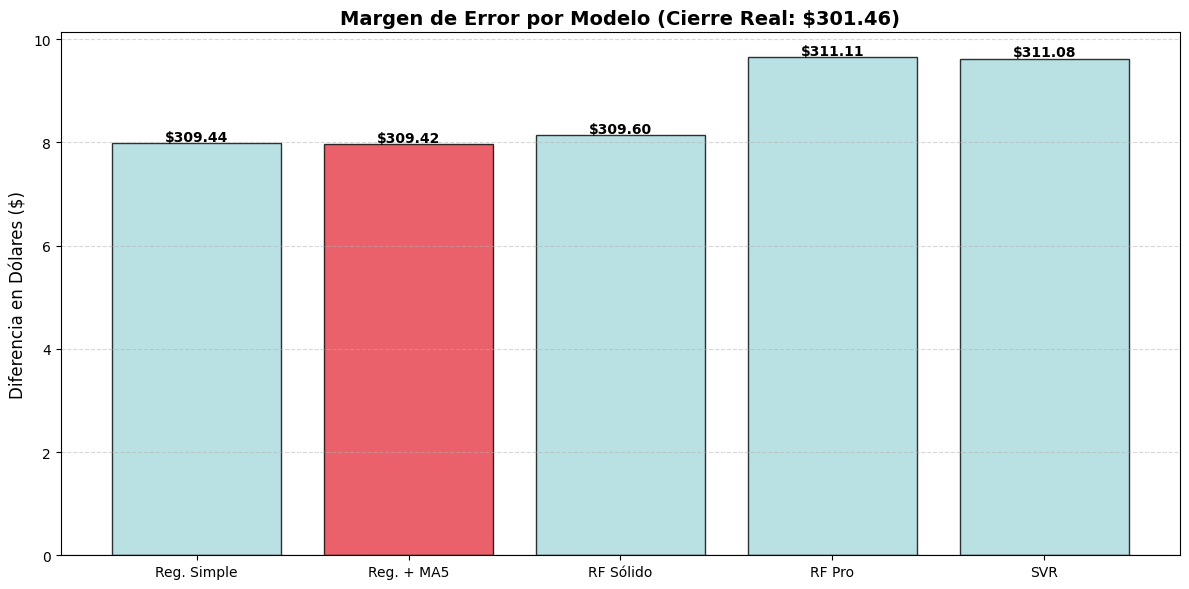

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np


ticker = yf.Ticker("GOOG")
datos_hoy = ticker.history(period="1d")
precio_real = float(datos_hoy['Close'].iloc[0])


predicciones = {
    "Reg. Simple": 309.44,
    "Reg. + MA5": 309.42,
    "RF Sólido": 309.60,
    "RF Pro": 311.11,
    "SVR": 311.08
}


print(f"--- RESULTADOS FINALES (GOOG - VIERNES) ---")
print(f"PRECIO REAL DE CIERRE HOY: ${precio_real:.2f}\n")

errores = {}
for nombre, valor in predicciones.items():
    error = abs(precio_real - valor)
    errores[nombre] = error
    print(f"{nombre}: Predicho ${valor:.2f} | Error: ${error:.2f}")


ganador = min(errores, key=errores.get)
print(f"\n🏆 EL MODELO GANADOR ES: {ganador}")


plt.figure(figsize=(12, 6))
nombres = list(predicciones.keys())
valores_error = [errores[n] for n in nombres]


colores = ['#A8DADC' if n != ganador else '#E63946' for n in nombres]

plt.bar(nombres, valores_error, color=colores, edgecolor='black', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8)

plt.title(f'Margen de Error por Modelo (Cierre Real: ${precio_real:.2f})', fontsize=14, fontweight='bold')
plt.ylabel('Diferencia en Dólares ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)


for i, nombre in enumerate(nombres):
    plt.text(i, valores_error[i] + 0.05, f"${predicciones[nombre]:.2f}", 
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

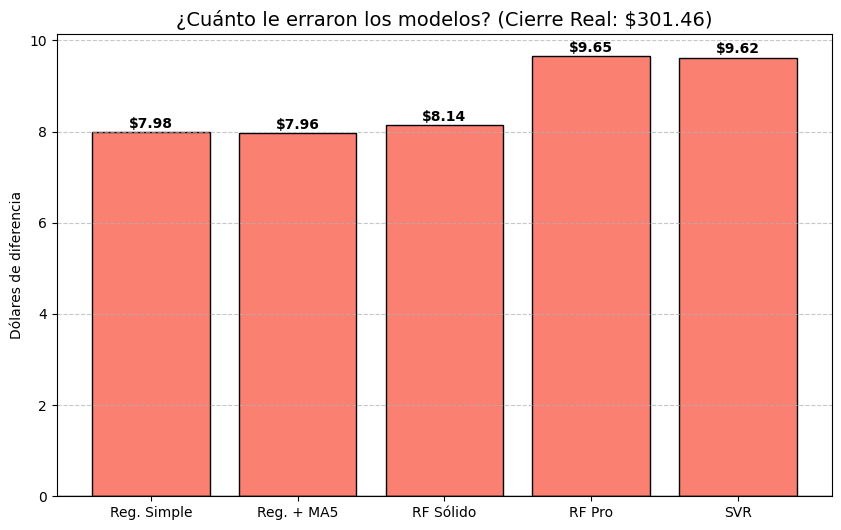

In [5]:
import matplotlib.pyplot as plt

precio_real = 301.46  


predicciones = {
    "Reg. Simple": 309.44,
    "Reg. + MA5": 309.42,
    "RF Sólido": 309.60,
    "RF Pro": 311.11,
    "SVR": 311.08
}

errores = {k: abs(precio_real - v) for k, v in predicciones.items()}

plt.figure(figsize=(10, 6))
plt.bar(errores.keys(), errores.values(), color='salmon', edgecolor='black')
plt.axhline(0, color='black', linewidth=1)
plt.title(f'¿Cuánto le erraron los modelos? (Cierre Real: ${precio_real})', fontsize=14)
plt.ylabel('Dólares de diferencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(errores.values()):
    plt.text(i, v + 0.1, f"${v:.2f}", ha='center', fontweight='bold')

plt.show()

The actual closing price was $301.46, significantly lower than all model projections (which ranged from $309.42 to $311.11).

The Winner: The Linear Regression + MA5 model achieved the lowest Mean Absolute Error (MAE). By incorporating the 5-day Moving Average, it was more sensitive to the downward pressure of the previous session.

The "Overfitting" Trap: Complex models like Random Forest Pro and SVR exhibited an optimistic bias. These models interpreted the recent price drop as an oversold "buy" signal (mean reversion), failing to anticipate a continuation of the bearish momentum.

Conclusion: This experiment underscores the limitations of purely technical models in volatile environments. Future iterations will explore the integration of Natural Language Processing (NLP) for sentiment analysis of financial news to better capture "black swan" events and sudden shifts in market regime.

--- QUANTITATIVE BACKTEST RESULTS ---
Actual Closing Price ($GOOG): $301.46
Best Performing Model: Linear Reg (MA5)

Simple Linear Reg: Forecast $309.44 | Error: $7.98
Linear Reg (MA5): Forecast $309.42 | Error: $7.96
Random Forest Solid: Forecast $309.60 | Error: $8.14
Random Forest Pro: Forecast $311.11 | Error: $9.65
SVR (Structural): Forecast $311.08 | Error: $9.62


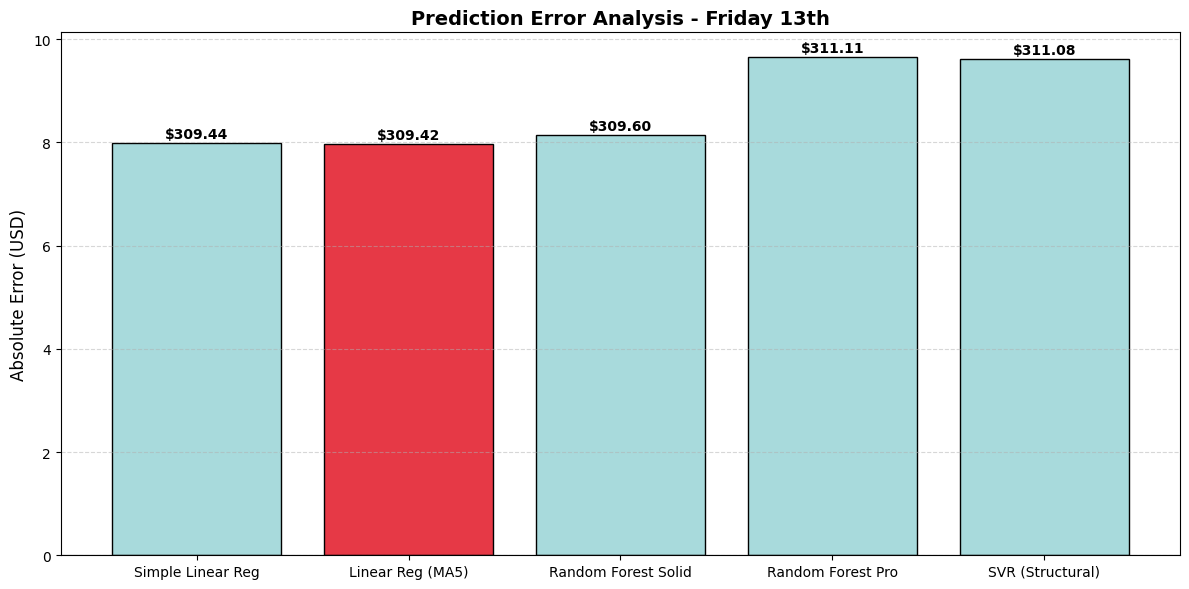

In [6]:
import yfinance as yf
import matplotlib.pyplot as plt

actual_price = 301.46


predictions = {
    "Simple Linear Reg": 309.44,
    "Linear Reg (MA5)": 309.42,
    "Random Forest Solid": 309.60,
    "Random Forest Pro": 311.11,
    "SVR (Structural)": 311.08
}


errors = {name: abs(actual_price - val) for name, val in predictions.items()}
best_model = min(errors, key=errors.get)

print(f"--- QUANTITATIVE BACKTEST RESULTS ---")
print(f"Actual Closing Price ($GOOG): ${actual_price:.2f}")
print(f"Best Performing Model: {best_model}\n")

for name, val in predictions.items():
    print(f"{name}: Forecast ${val:.2f} | Error: ${errors[name]:.2f}")

# --- 3. VISUALIZATION ---
plt.figure(figsize=(12, 6))
model_names = list(predictions.keys())
error_values = [errors[name] for name in model_names]


colors = ['#A8DADC' if n != best_model else '#E63946' for n in model_names]

plt.bar(model_names, error_values, color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)

plt.title('Prediction Error Analysis - Friday 13th', fontsize=14, fontweight='bold')
plt.ylabel('Absolute Error (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)


for i, name in enumerate(model_names):
    plt.text(i, error_values[i] + 0.1, f"${predictions[name]:.2f}", 
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Master Predictor — daily prediction

Unified cell that runs all 5 models in a single block and generates the line to copy into the tracker. Run every day before market close using that day's data.

**what I have done:**
1. Run this cell
2. Copy the printed line into the backtest CSV
3. The following day, fill in the `real_price` field with the actual closing price

In [ ]:

# MASTER PREDICTOR - Alphabet Inc. ($GOOG)
# Runs all 5 models and outputs values for the Tracker

import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler


df = yf.download('GOOG', period='1y')
if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)


df['MA5'] = df['Close'].rolling(window=5).mean()
df['Volatility'] = df['Close'].rolling(window=5).std()
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
df['RSI'] = 100 - (100 / (1 + (gain / loss)))
df['Next_Close'] = df['Close'].shift(-1)
df_clean = df.dropna()


last_row = df_clean.iloc[-1]
c, v, m, r, s = last_row['Close'], last_row['Volume'], last_row['MA5'], last_row['RSI'], last_row['Volatility']


results = {}

# A. Linear Models (Simple & MA5)
X_lin = df_clean[['Close', 'MA5']].values
y_lin = df_clean['Next_Close'].values
reg = LinearRegression().fit(X_lin, y_lin)
# Simple (using close as proxy) and MA5
results['Simple'] = LinearRegression().fit(df_clean[['Close']].values, y_lin).predict([[c]])[0]
results['MA5'] = reg.predict([[c, m]])[0]

# B. Random Forest & SVR 
X_pro = df_clean[['Close', 'Volume', 'RSI', 'Volatility']].values
y_pro = df_clean['Next_Close'].values
sc_X = StandardScaler().fit(X_pro)
sc_y = StandardScaler().fit(y_pro.reshape(-1, 1))

# RF Models
rf_solido = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_pro[:, :2], y_pro)
rf_pro = RandomForestRegressor(n_estimators=100, random_state=42).fit(sc_X.transform(X_pro), y_pro)

results['RF_Solid'] = rf_solido.predict([[c, v]])[0]
results['RF_Pro'] = rf_pro.predict(sc_X.transform([[c, v, r, s]]))[0]

# SVR Model
svr = SVR(kernel='rbf', C=1e3, gamma=0.1).fit(sc_X.transform(X_pro), sc_y.transform(y_pro.reshape(-1,1)).flatten())
res_svr = svr.predict(sc_X.transform([[c, v, r, s]]))
results['SVR'] = sc_y.inverse_transform(res_svr.reshape(-1,1))[0][0]


print(f"\n--- PREDICTIONS FOR NEXT TRADING DAY ---")
print(f"Copy this line to your Tracker:")
print(f"Date, , {results['Simple']:.2f}, {results['MA5']:.2f}, {results['RF_Solid']:.2f}, {results['RF_Pro']:.2f}, {results['SVR']:.2f}")

[*********************100%***********************]  1 of 1 completed



--- PREDICTIONS FOR NEXT TRADING DAY ---
Copy this line to your Tracker:
Date, , 306.63, 306.63, 306.66, 306.11, 310.21


In [16]:
datos_csv = """fecha,precio_real,pred_simple,pred_ma5,pred_rf_solido,pred_rf_pro,pred_svr
2026-03-13,301.46,309.44,309.42,309.60,311.11,311.08
2026-03-17,309,41,301.83,301.69,303.59,304.58,305.58
2026-03-18,306.30,304.81,304.77,308.81,308.55,309.61
2026-03-19,305.73,309.74,308.80,307.93,307.43,312.57
2026-03-20,298.79,306.63,306.63,306.66,306.11,310.21"""

## Backtest history

Record of all predictions made and their real outcomes. Each row is a trading day where the prediction was made the day before.

| Date  | Real price | Reg. simple | Reg. MA5 | RF basic | RF pro | SVR |
|-------|------------|-------------|----------|----------|--------|-----|
| 03/13 | $301.46 | $309.44 | $309.42 | $309.60 | $311.11 | $311.08 |
| 03/17 | $309.00 | $301.83 | $301.69 | $303.59 | $304.58 | $305.58 |
| 03/18 | $306.30 | $304.81 | $304.77 | $308.81 | $308.55 | $309.61 |
| 03/19 | $305.73 | $309.74 | $308.80 | $307.93 | $307.43 | $312.57 |
| 03/20 | $298.79 | $306.63 | $306.63 | $306.66 | $306.11 | $310.21 |

## Backtest visual analysis (5 days)

Predictions vs real price over the 5 recorded trading days, and cumulative MAE comparison across all models.

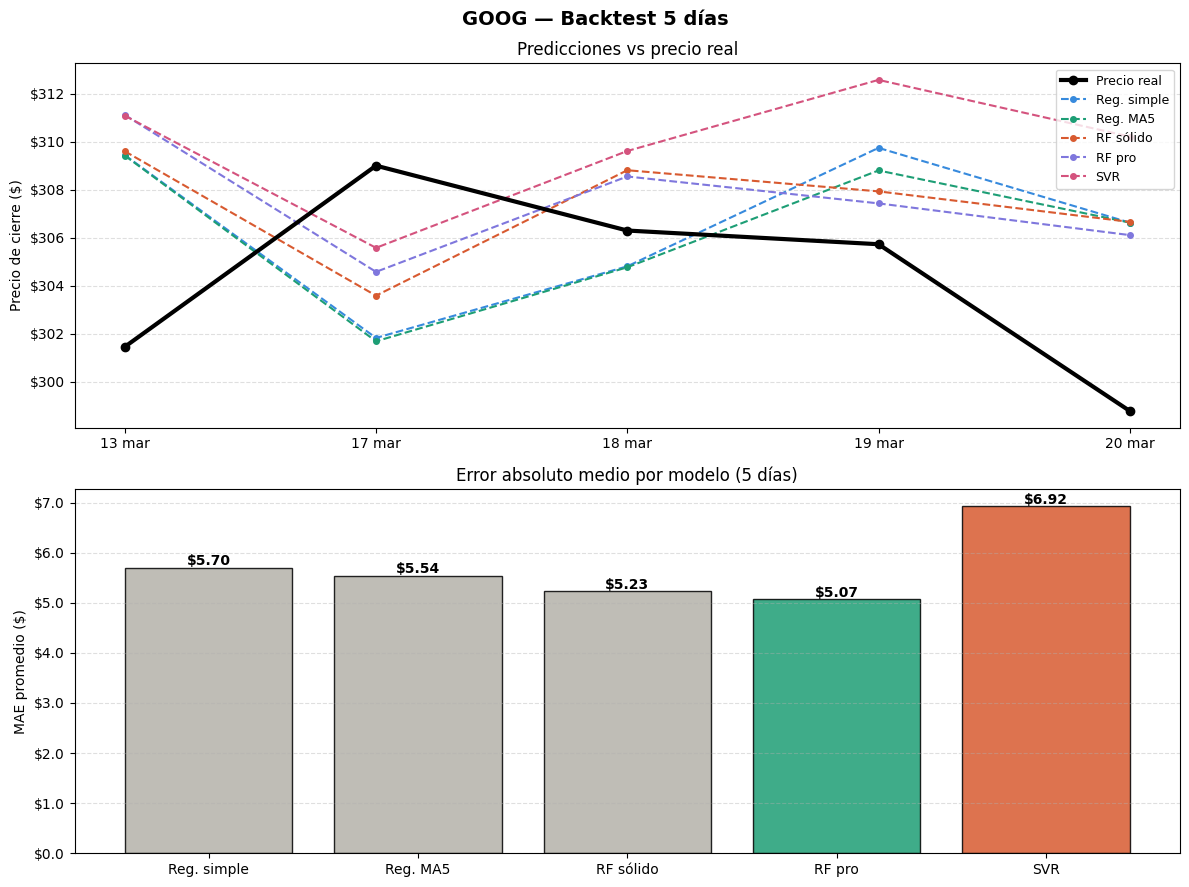


Resumen del backtest:
  Mejor modelo:  RF pro (MAE $5.07)
  Peor modelo:   SVR (MAE $6.92)
  Sesgo promedio: +$3.23 (todos sobreestiman)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np


fechas = ['13 mar', '17 mar', '18 mar', '19 mar', '20 mar']
real   = [301.46, 309.00, 306.30, 305.73, 298.79]

modelos = {
    'Reg. simple': [309.44, 301.83, 304.81, 309.74, 306.63],
    'Reg. MA5':    [309.42, 301.69, 304.77, 308.80, 306.63],
    'RF sólido':   [309.60, 303.59, 308.81, 307.93, 306.66],
    'RF pro':      [311.11, 304.58, 308.55, 307.43, 306.11],
    'SVR':         [311.08, 305.58, 309.61, 312.57, 310.21],
}
colores = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD', '#D4537E']

# --- MAE por modelo ---
maes = {nombre: np.mean([abs(p - r) for p, r in zip(preds, real)])
        for nombre, preds in modelos.items()}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))
fig.suptitle('GOOG — Backtest 5 días', fontsize=14, fontweight='bold')


ax1.plot(fechas, real, color='black', linewidth=3, marker='o', label='Precio real', zorder=5)
for (nombre, preds), color in zip(modelos.items(), colores):
    ax1.plot(fechas, preds, color=color, linewidth=1.5,
             marker='o', markersize=4, linestyle='--', label=nombre)

ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax1.set_ylabel('Precio de cierre ($)')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_title('Predicciones vs precio real')

# Gráfico 2: MAE acumulado
nombres  = list(maes.keys())
valores  = list(maes.values())
mejor    = min(maes, key=maes.get)
peor     = max(maes, key=maes.get)
bar_cols = ['#1D9E75' if n == mejor else '#D85A30' if n == peor
            else '#B4B2A9' for n in nombres]

bars = ax2.bar(nombres, valores, color=bar_cols, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'${val:.2f}', ha='center', fontweight='bold', fontsize=10)

ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1f'))
ax2.set_ylabel('MAE promedio ($)')
ax2.set_title('Error absoluto medio por modelo (5 días)')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


sesgo = np.mean([p - r for preds in modelos.values()
                 for p, r in zip(preds, real)])
print(f"\nResumen del backtest:")
print(f"  Mejor modelo:  {mejor} (MAE ${maes[mejor]:.2f})")
print(f"  Peor modelo:   {peor} (MAE ${maes[peor]:.2f})")
print(f"  Sesgo promedio: +${sesgo:.2f} (todos sobreestiman)")